# ATI Project — Music Genre Classification (FMA-small)
## Phase 2 · Modeling and evaluation

### 1. Load feature file

In [12]:
CSV_PATH = "fma_small_features.csv"
print("File:", CSV_PATH)

File: fma_small_features.csv


In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
RANDOM_STATE = 42

### 2. Load data and split into train/validation/test

In [4]:
# Load data and build the official train/val/test split
df = pd.read_csv(CSV_PATH)
print("Shape:", df.shape)

feature_cols = [c for c in df.columns if c not in ("track_id", "genre", "split")]
X = df[feature_cols].values
y = df["genre"].values
split = df["split"].values

tr, va, te = split == "training", split == "validation", split == "test"
X_train, y_train = X[tr], y[tr]
X_val,   y_val   = X[va], y[va]
X_test,  y_test  = X[te], y[te]
print(f"train={tr.sum()}  val={va.sum()}  test={te.sum()}  | n_features={len(feature_cols)}")

# Standardize (fit on train only)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

Shape: (7994, 92)
train=6394  val=800  test=800  | n_features=89


### 3. Baseline

In [5]:
def evaluar(modelo, Xtr, ytr, Xev, yev, nombre):
    """Fit a model and report accuracy and macro-F1 on an evaluation set."""
    modelo.fit(Xtr, ytr)
    pred = modelo.predict(Xev)
    acc = accuracy_score(yev, pred)
    f1  = f1_score(yev, pred, average="macro")
    print(f"{nombre:22s} acc={acc:.3f}  f1_macro={f1:.3f}")
    return acc, f1

print("== Baseline (evaluated on VALIDATION) ==")
evaluar(DummyClassifier(strategy="most_frequent"), X_train_s, y_train, X_val_s, y_val, "Dummy (majority)")
evaluar(KNeighborsClassifier(n_neighbors=5),       X_train_s, y_train, X_val_s, y_val, "k-NN (k=5)")

== Baseline (evaluated on VALIDATION) ==
Dummy (majority)       acc=0.125  f1_macro=0.028
k-NN (k=5)             acc=0.451  f1_macro=0.440


(0.45125, 0.43972865217600865)

### 4. Candidate models

In [6]:
modelos = {
    "Logistic Regression": LogisticRegression(max_iter=2000, C=1.0),
    "Random Forest":       RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "SVM (RBF)":           SVC(kernel="rbf", C=10, gamma="scale"),
    "Gradient Boosting":   HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}
print("== Models (evaluated on VALIDATION) ==")
resultados = {}
for nombre, m in modelos.items():
    resultados[nombre] = evaluar(m, X_train_s, y_train, X_val_s, y_val, nombre)

== Models (evaluated on VALIDATION) ==
Logistic Regression    acc=0.481  f1_macro=0.472
Random Forest          acc=0.531  f1_macro=0.524
SVM (RBF)              acc=0.529  f1_macro=0.521
Gradient Boosting      acc=0.521  f1_macro=0.522


### 5. Hyperparameter tuning

In [7]:
# Hyperparameter tuning with PredefinedSplit (-1 = train, 0 = validation)
X_tv = np.vstack([X_train_s, X_val_s])
y_tv = np.concatenate([y_train, y_val])
fold = np.concatenate([np.full(len(y_train), -1), np.zeros(len(y_val))])
ps = PredefinedSplit(fold)

param_grid = {
    "n_estimators": [200, 400],
    "max_depth":    [None, 20, 40],
    "min_samples_leaf": [1, 2, 5],
}
gs = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid, scoring="f1_macro", cv=ps, n_jobs=-1, verbose=1,
)
gs.fit(X_tv, y_tv)
print("Best params:", gs.best_params_)
print("Best macro-F1 (val):", round(gs.best_score_, 3))

Fitting 1 folds for each of 18 candidates, totalling 18 fits
Best params: {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 200}
Best macro-F1 (val): 0.527


### 6. Final evaluation on TEST

In [8]:
# Refit the tuned model on train+val and evaluate once on test
modelo_final = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **gs.best_params_)
modelo_final.fit(X_tv, y_tv)
y_pred = modelo_final.predict(X_test_s)

print("Test accuracy :", round(accuracy_score(y_test, y_pred), 3))
print("Test macro-F1 :", round(f1_score(y_test, y_pred, average="macro"), 3))
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

Test accuracy : 0.42
Test macro-F1 : 0.415

Classification report:

               precision    recall  f1-score   support

   Electronic       0.49      0.51      0.50       100
 Experimental       0.30      0.20      0.24       100
         Folk       0.20      0.21      0.20       100
      Hip-Hop       0.59      0.66      0.63       100
 Instrumental       0.37      0.37      0.37       100
International       0.47      0.52      0.50       100
          Pop       0.31      0.31      0.31       100
         Rock       0.57      0.58      0.57       100

     accuracy                           0.42       800
    macro avg       0.41      0.42      0.41       800
 weighted avg       0.41      0.42      0.41       800



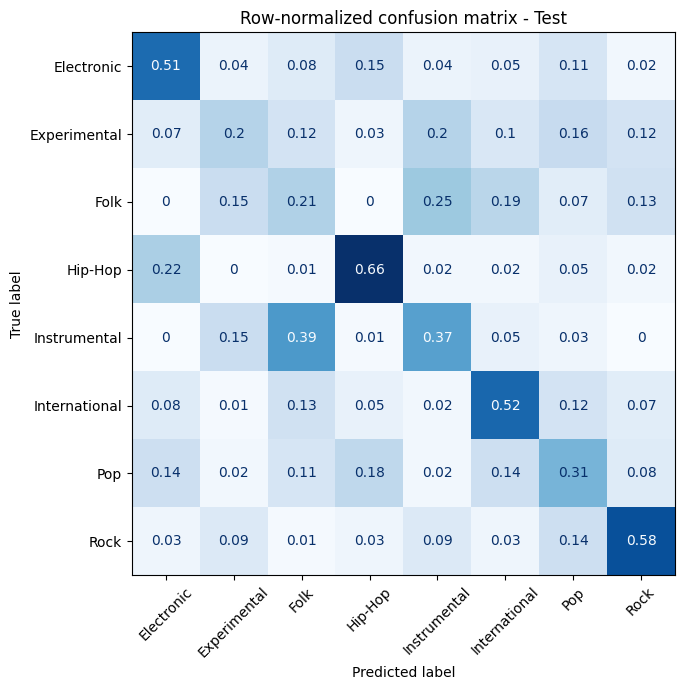

In [9]:
# Confusion matrix
labels = sorted(np.unique(y))
cm = confusion_matrix(y_test, y_pred, labels=labels, normalize="true")
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Row-normalized confusion matrix - Test")
plt.tight_layout(); plt.show()

### 7. Error analysis

Top 15 most important features:

contrast2_mean    0.0231
contrast1_mean    0.0209
mfcc0_mean        0.0195
bandwidth_mean    0.0185
centroid_std      0.0183
centroid_mean     0.0181
contrast3_mean    0.0173
rolloff_mean      0.0168
contrast4_mean    0.0161
rms_std           0.0158
mfcc1_mean        0.0156
mfcc2_mean        0.0147
rolloff_std       0.0144
zcr_mean          0.0140
rms_mean          0.0132
dtype: float64


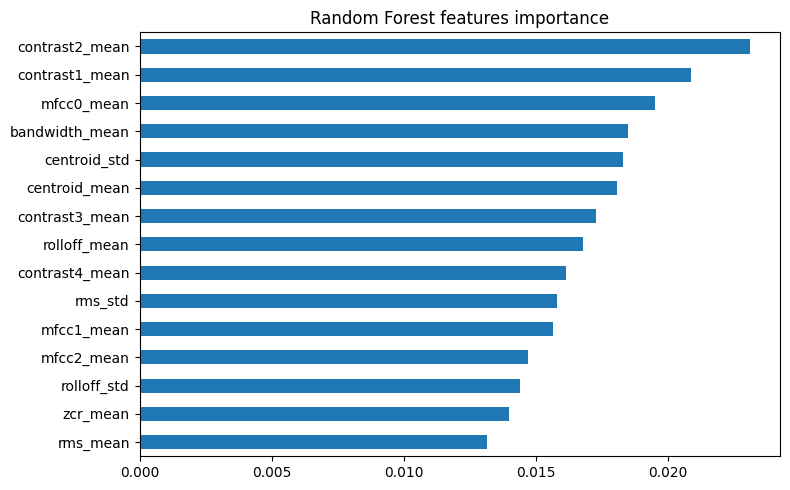

In [10]:
# Feature importances
imp = pd.Series(modelo_final.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("Top 15 most important features:\n")
print(imp.head(15).round(4))

plt.figure(figsize=(8, 5))
imp.head(15)[::-1].plot(kind="barh")
plt.title("Random Forest features importance")
plt.tight_layout(); plt.show()

In [11]:
# Most-confused genre pairs
cm_counts = confusion_matrix(y_test, y_pred, labels=labels)
pares = []
for i, gi in enumerate(labels):
    for j, gj in enumerate(labels):
        if i != j and cm_counts[i, j] > 0:
            pares.append((gi, gj, cm_counts[i, j]))
pares.sort(key=lambda t: t[2], reverse=True)
print("Most frequent confusions (true -> predicted : count):")
for real, pred, n in pares[:10]:
    print(f"  {real:14s} -> {pred:14s} : {n}")

Most frequent confusions (true -> predicted : count):
  Instrumental   -> Folk           : 39
  Folk           -> Instrumental   : 25
  Hip-Hop        -> Electronic     : 22
  Experimental   -> Instrumental   : 20
  Folk           -> International  : 19
  Pop            -> Hip-Hop        : 18
  Experimental   -> Pop            : 16
  Electronic     -> Hip-Hop        : 15
  Folk           -> Experimental   : 15
  Instrumental   -> Experimental   : 15
